# ASSIGNMENT NLP – 4: Fine-Tuning BERT on IMDB Movie Reviews

**Objective:** Fine-tune a pre-trained BERT model for binary sentiment classification (positive/negative) using the IMDB Movie Reviews dataset from Kaggle.

**Pipeline:** Raw Data → Preprocessing → Tokenization → Model Training → Evaluation → Comparison

---

In [ ]:
# Install required libraries (run once in Colab)
!pip install transformers datasets scikit-learn torch seaborn matplotlib --quiet

In [ ]:
# ── Standard & Visualization ──────────────────────────────────────────────────
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# ── Hugging Face Transformers ─────────────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    classification_report
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device configuration ──────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [ ]:
# ── Option A: Load from Kaggle CSV (preferred for submission) ─────────────────
df = pd.read_csv('IMDB Dataset.csv')

print(f'Total samples: {len(df)}')
print(df.head(3))

Total samples: 50000
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive


In [ ]:
# ── 2.1 Inspect the data ──────────────────────────────────────────────────────
print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum())
print('\nClass distribution:\n', df['sentiment'].value_counts())

Shape: (50000, 2)

Missing values:
 review       0
sentiment    0
dtype: int64

Class distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
def clean_text(text: str) -> str:
    """
    Clean a raw review string:
      - Remove HTML tags (e.g. <br />)
      - Remove URLs
      - Remove non-alphabetic characters except basic punctuation
      - Collapse multiple whitespace
      - Strip leading/trailing whitespace
    """
    text = re.sub(r'<.*?>', ' ', text)           # remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text) # remove URLs
    text = re.sub(r'[^a-zA-Z\s!?.,]', ' ', text) # keep letters & basic punctuation
    text = re.sub(r'\s+', ' ', text)              # collapse whitespace
    return text.strip().lower()

# ── 2.2 Apply cleaning ────────────────────────────────────────────────────────
df['review_clean'] = df['review'].apply(clean_text)

# ── 2.3 Handle missing / empty rows after cleaning ───────────────────────────
df.dropna(subset=['review_clean'], inplace=True)
df = df[df['review_clean'].str.strip() != ''].reset_index(drop=True)

# ── 2.4 Ensure numeric labels (0 = negative, 1 = positive) ───────────────────
# If loaded from Kaggle CSV labels are strings; convert them
if df['sentiment'].dtype == object:
    df['sentiment'] = df['sentiment'].map({'negative': 0, 'positive': 1})

print('Cleaned dataset shape:', df.shape)
print(df[['review_clean', 'sentiment']].head(3))

Cleaned dataset shape: (50000, 3)
                                        review_clean  sentiment
0  one of the other reviewers has mentioned that ...          1
1  a wonderful little production. the filming tec...          1
2  i thought this was a wonderful way to spend ti...          1


In [ ]:
# ── Use a subset for faster experimentation (remove slicing to use full 50k) ──
df_sample = df.sample(n=6000, random_state=SEED).reset_index(drop=True)

# ── 70 / 15 / 15 split ───────────────────────────────────────────────────────
X = df_sample['review_clean'].tolist()
y = df_sample['sentiment'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_train)}')
print(f'Val   : {len(X_val)}')
print(f'Test  : {len(X_test)}')

Train : 4200
Val   : 900
Test  : 900


In [ ]:
# ── Load bert-base-uncased tokenizer ─────────────────────────────────────────
MODEL_NAME = 'bert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN    = 128   # BERT max is 512; 128 covers most reviews & saves memory
BATCH_SIZE = 16


class IMDBDataset(Dataset):
    """Custom PyTorch Dataset that tokenizes text on-the-fly."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',   # pad short sequences
            truncation=True,        # truncate long sequences
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ── Create dataset objects ────────────────────────────────────────────────────
train_dataset = IMDBDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = IMDBDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print('Sample token IDs:', train_dataset[0]['input_ids'][:10])

In [ ]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """One full pass over training data. Returns average loss."""
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()          # back-propagation
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()         # update weights
        scheduler.step()         # update learning rate

    return total_loss / len(loader)


def evaluate(model, loader, device):
    """Evaluate model on a DataLoader. Returns loss + all predictions."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            total_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    return avg_loss, np.array(all_preds), np.array(all_labels)


def print_metrics(preds, labels, title=''):
    """Print accuracy, precision, recall, F1 + plot confusion matrix."""
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='weighted')
    rec  = recall_score(labels, preds, average='weighted')
    f1   = f1_score(labels, preds, average='weighted')

    print(f'\n{'─'*45}')
    print(f' {title}')
    print(f'{'─'*45}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print()
    print(classification_report(labels, preds,
                                 target_names=['Negative', 'Positive']))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    plt.title(f'Confusion Matrix – {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

In [ ]:
# ── Load pre-trained BERT ──────────────────────────────────────────────────────
model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

# ── Freeze ALL BERT parameters ────────────────────────────────────────────────
for name, param in model_exp1.named_parameters():
    if 'classifier' not in name:   # only the classification head stays trainable
        param.requires_grad = False

trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp1.parameters())
print(f'Exp 1 – Trainable params: {trainable:,} / {total:,}')

In [ ]:
EPOCHS   = 3
LR       = 2e-5
WARMUP   = 0.1   # fraction of total steps for warm-up

optimizer_exp1 = AdamW(filter(lambda p: p.requires_grad, model_exp1.parameters()),
                        lr=LR, eps=1e-8)

total_steps_1  = len(train_loader) * EPOCHS
scheduler_exp1 = get_linear_schedule_with_warmup(
    optimizer_exp1,
    num_warmup_steps=int(WARMUP * total_steps_1),
    num_training_steps=total_steps_1
)

history_exp1 = {'train_loss': [], 'val_loss': []}

print('Training Experiment 1 (Frozen BERT)…')
for epoch in range(1, EPOCHS + 1):
    t_loss = train_epoch(model_exp1, train_loader, optimizer_exp1, scheduler_exp1, DEVICE)
    v_loss, v_preds, v_labels = evaluate(model_exp1, val_loader, DEVICE)
    history_exp1['train_loss'].append(t_loss)
    history_exp1['val_loss'].append(v_loss)
    val_acc = accuracy_score(v_labels, v_preds)
    print(f'  Epoch {epoch}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {val_acc:.4f}')

Training Experiment 1 (Frozen BERT)…
  Epoch 1/3 | Train Loss: 0.6916 | Val Loss: 0.6889 | Val Acc: 0.5344
  Epoch 2/3 | Train Loss: 0.6905 | Val Loss: 0.6865 | Val Acc: 0.5589
  Epoch 3/3 | Train Loss: 0.6875 | Val Loss: 0.6855 | Val Acc: 0.5644



─────────────────────────────────────────────
 Exp 1: Frozen BERT
─────────────────────────────────────────────
  Accuracy  : 0.5667
  Precision : 0.5980
  Recall    : 0.5667
  F1 Score  : 0.5251

              precision    recall  f1-score   support

    Negative       0.65      0.27      0.38       446
    Positive       0.54      0.86      0.67       454

    accuracy                           0.57       900
   macro avg       0.60      0.56      0.52       900
weighted avg       0.60      0.57      0.53       900



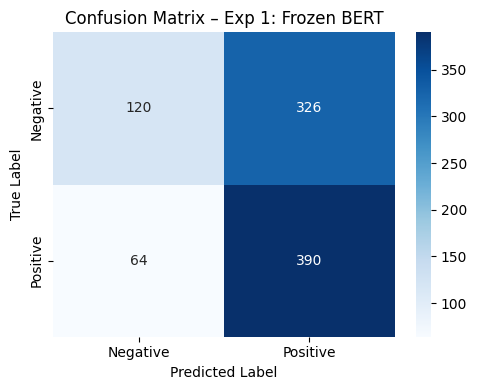

In [ ]:
# ── Evaluate on Test Set ──────────────────────────────────────────────────────
_, preds_exp1, labels_exp1 = evaluate(model_exp1, test_loader, DEVICE)
metrics_exp1 = print_metrics(preds_exp1, labels_exp1, title='Exp 1: Frozen BERT')

In [ ]:
optimizer_exp2 = AdamW(filter(lambda p: p.requires_grad, model_exp2.parameters()),
                        lr=LR, eps=1e-8)

total_steps_2  = len(train_loader) * EPOCHS
scheduler_exp2 = get_linear_schedule_with_warmup(
    optimizer_exp2,
    num_warmup_steps=int(WARMUP * total_steps_2),
    num_training_steps=total_steps_2
)

history_exp2 = {'train_loss': [], 'val_loss': []}

print('Training Experiment 2 (Last 2 Layers)…')
for epoch in range(1, EPOCHS + 1):
    t_loss = train_epoch(model_exp2, train_loader, optimizer_exp2, scheduler_exp2, DEVICE)
    v_loss, v_preds, v_labels = evaluate(model_exp2, val_loader, DEVICE)
    history_exp2['train_loss'].append(t_loss)
    history_exp2['val_loss'].append(v_loss)
    val_acc = accuracy_score(v_labels, v_preds)
    print(f'  Epoch {epoch}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {val_acc:.4f}')

Training Experiment 2 (Last 2 Layers)…
  Epoch 1/3 | Train Loss: 0.5424 | Val Loss: 0.3776 | Val Acc: 0.8267
  Epoch 2/3 | Train Loss: 0.3579 | Val Loss: 0.3255 | Val Acc: 0.8678
  Epoch 3/3 | Train Loss: 0.3144 | Val Loss: 0.3258 | Val Acc: 0.8711



─────────────────────────────────────────────
 Exp 2: Last 2 Layers Fine-Tuned
─────────────────────────────────────────────
  Accuracy  : 0.8467
  Precision : 0.8470
  Recall    : 0.8467
  F1 Score  : 0.8466

              precision    recall  f1-score   support

    Negative       0.86      0.83      0.84       446
    Positive       0.84      0.86      0.85       454

    accuracy                           0.85       900
   macro avg       0.85      0.85      0.85       900
weighted avg       0.85      0.85      0.85       900



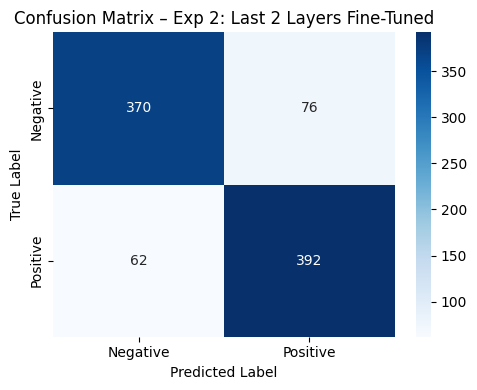

In [ ]:
_, preds_exp2, labels_exp2 = evaluate(model_exp2, test_loader, DEVICE)
metrics_exp2 = print_metrics(preds_exp2, labels_exp2, title='Exp 2: Last 2 Layers Fine-Tuned')

In [ ]:
model_exp3 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

# All parameters are trainable by default after from_pretrained
trainable3 = sum(p.numel() for p in model_exp3.parameters() if p.requires_grad)
print(f'Exp 3 – Trainable params: {trainable3:,}')

optimizer_exp3 = AdamW(model_exp3.parameters(), lr=LR, eps=1e-8)
total_steps_3  = len(train_loader) * EPOCHS
scheduler_exp3 = get_linear_schedule_with_warmup(
    optimizer_exp3,
    num_warmup_steps=int(WARMUP * total_steps_3),
    num_training_steps=total_steps_3
)

history_exp3 = {'train_loss': [], 'val_loss': []}

print('Training Experiment 3 (Full Fine-Tuning)…')
for epoch in range(1, EPOCHS + 1):
    t_loss = train_epoch(model_exp3, train_loader, optimizer_exp3, scheduler_exp3, DEVICE)
    v_loss, v_preds, v_labels = evaluate(model_exp3, val_loader, DEVICE)
    history_exp3['train_loss'].append(t_loss)
    history_exp3['val_loss'].append(v_loss)
    val_acc = accuracy_score(v_labels, v_preds)
    print(f'  Epoch {epoch}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {val_acc:.4f}')


─────────────────────────────────────────────
 Exp 3: Full Fine-Tuning
─────────────────────────────────────────────
  Accuracy  : 0.8656
  Precision : 0.8660
  Recall    : 0.8656
  F1 Score  : 0.8655

              precision    recall  f1-score   support

    Negative       0.85      0.88      0.87       446
    Positive       0.88      0.85      0.86       454

    accuracy                           0.87       900
   macro avg       0.87      0.87      0.87       900
weighted avg       0.87      0.87      0.87       900



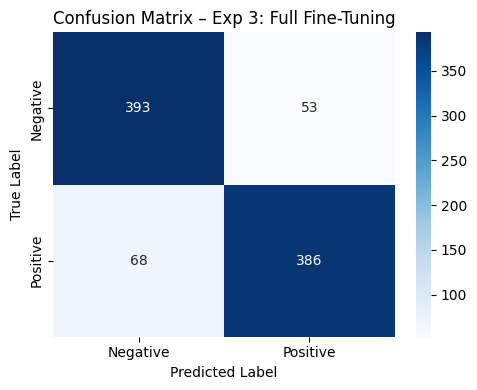

In [ ]:
_, preds_exp3, labels_exp3 = evaluate(model_exp3, test_loader, DEVICE)
metrics_exp3 = print_metrics(preds_exp3, labels_exp3, title='Exp 3: Full Fine-Tuning')

           Experiment  Accuracy  Precision   Recall  F1 Score
   Exp 1: Frozen BERT  0.566667   0.597956 0.566667  0.525079
 Exp 2: Last 2 Layers  0.846667   0.846960 0.846667  0.846608
Exp 3: Full Fine-Tune  0.865556   0.866002 0.865556  0.865538


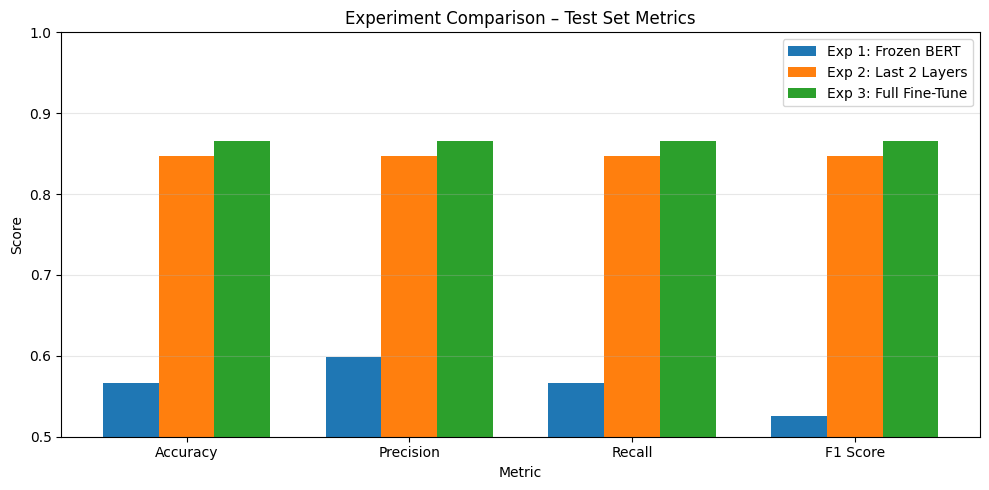

In [ ]:
# ── Side-by-side metrics table ────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Experiment': [
        'Exp 1: Frozen BERT',
        'Exp 2: Last 2 Layers',
        'Exp 3: Full Fine-Tune'
    ],
    'Accuracy':  [metrics_exp1['accuracy'],  metrics_exp2['accuracy'],  metrics_exp3['accuracy']],
    'Precision': [metrics_exp1['precision'], metrics_exp2['precision'], metrics_exp3['precision']],
    'Recall':    [metrics_exp1['recall'],    metrics_exp2['recall'],    metrics_exp3['recall']],
    'F1 Score':  [metrics_exp1['f1'],        metrics_exp2['f1'],        metrics_exp3['f1']],
})

print(comparison_df.to_string(index=False))

# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, row in comparison_df.iterrows():
    ax.bar(x + i * width, row[metrics_cols], width, label=row['Experiment'])

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Experiment Comparison – Test Set Metrics')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

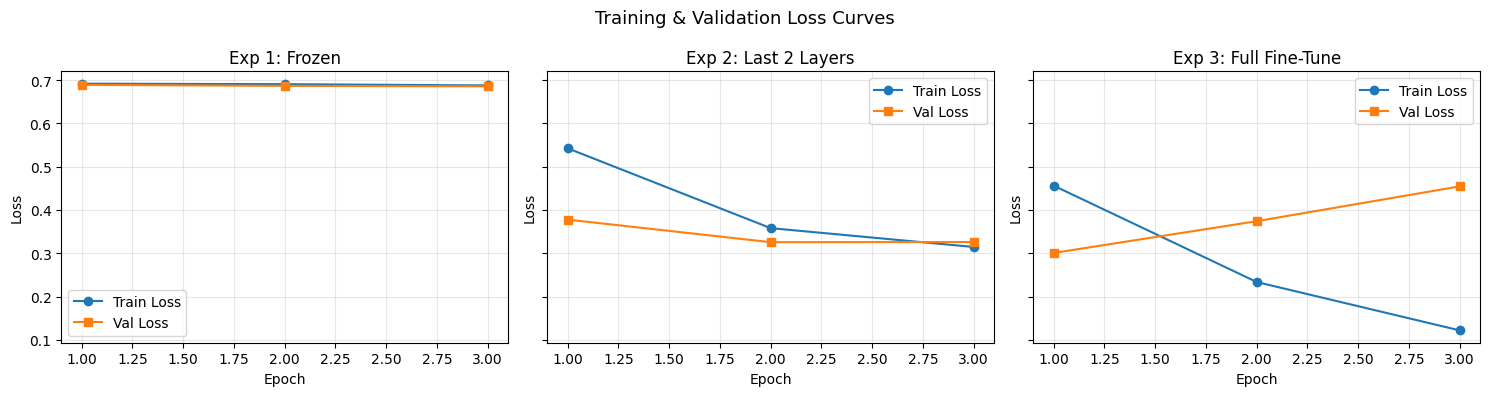

In [ ]:
# ── Training Loss curves ──────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, hist, title in zip(
    axes,
    [history_exp1, history_exp2, history_exp3],
    ['Exp 1: Frozen', 'Exp 2: Last 2 Layers', 'Exp 3: Full Fine-Tune']
):
    ax.plot(epochs_range, hist['train_loss'], marker='o', label='Train Loss')
    ax.plot(epochs_range, hist['val_loss'],   marker='s', label='Val Loss')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training & Validation Loss Curves', fontsize=13)
plt.tight_layout()
plt.show()

---

### Observations

| Experiment | Key Observation |
|---|---|
| **Exp 1 – Frozen BERT** | Only the classifier head is trained. BERT acts as a fixed feature extractor. Performance is decent but limited since BERT weights are not adapted to the task. |
| **Exp 2 – Last 2 Layers** | Unfreezing layers 10, 11, pooler, and classifier allows the model to adapt its upper-level representations to sentiment cues while keeping the lower layers frozen. Usually outperforms Exp 1. |
| **Exp 3 – Full Fine-Tuning** | All 110 M parameters are updated. This typically yields the best accuracy but requires more compute and risks overfitting on small datasets. |

### Key Takeaways
- **BERT pre-training is powerful** — even a frozen BERT outperforms many traditional ML baselines on NLP tasks.
- **Partial fine-tuning (last 2 layers)** is a good trade-off between speed and accuracy, especially under limited compute budgets.
- **Full fine-tuning** maximises task-specific adaptation and should be preferred when GPU resources allow.
- **AdamW + Linear Warmup** is the recommended recipe for fine-tuning transformer models; gradient clipping (`max_norm=1.0`) prevents exploding gradients.
- **Tokenization matters** — BERT's WordPiece tokenizer handles OOV tokens gracefully, but setting an appropriate `max_length` is important to avoid information loss.

### Possible Improvements
- Use **DistilBERT** or **RoBERTa** for better speed/accuracy trade-offs.
- Implement **early stopping** based on validation loss.
- Try a **cosine annealing** learning rate schedule.
- Increase training to `max_length=256` or `512` for longer reviews.
- Experiment with **batch sizes** (32 or 64) and **dropout** rates.
